In [1]:
import os
import json
import torch
import random
import numpy as np
import pandas as pd 

from torch.optim import Adam
from omegaconf import OmegaConf
from torch.backends import cudnn
from argparse import ArgumentParser
from torch.nn import functional as F
from easydict import EasyDict as edict
from trainers.cbm_trainer import DiceLosswithRegularizer
from accelerate import Accelerator, DistributedDataParallelKwargs

from datasets import build_dataset
from trainers import build_trainer
from utils import LearningRateFinder, build_dataloaders
from models.build_models import load_clip_and_tokenizer, create_diffusion, load_clipcbn_preprocessor

2025-02-21 04:07:35.682898: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-02-21 04:07:35.690189: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-02-21 04:07:35.698401: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8454] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-02-21 04:07:35.700751: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1452] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-02-21 04:07:35.707280: I tensorflow/core/platform/cpu_feature_guar

In [2]:
# Setting reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

In [3]:
def parse_args(task='test', config='configs/cbm_bioparse/covidct_left+lung_s.yaml', num_workers=0,
               exp_name='covidct_left+lung_s', device='cuda', learn_obj='cbm', 
               distribution_training=False, load_checkpoint=False, test_type='test'):
    """
    Parse arguments for the experiment.

    Parameters:
    - task (str): The task to perform.
    - config (str): Path to the config file.
    - num_workers (int): Number of workers for dataloader.
    - exp_name (str): The name of the experiment.
    - device (str): Experiment device.
    - learn_obj (str): The learning objective.
    - distribution_training (bool): Enable distribution training.
    - load_checkpoint (bool): Load checkpoint.
    - test_type (str): The test dataset.

    Returns:
    - dict: A dictionary containing the arguments.
    """
    
    # Define valid choices for the arguments
    task_choices = ['train', 'inf', 'test', 'vis_process', 'thresh_search', 'lr_search', 'produce_cam']
    learn_obj_choices = ['recflow', 'ddpm', 'ddpmpp', 'recflowturb', 'cbm', 'dice']

    # Check validity of the parameters
    if task not in task_choices:
        raise ValueError(f"Invalid task: {task}. Choose from {task_choices}.")
    
    if learn_obj not in learn_obj_choices:
        raise ValueError(f"Invalid learning objective: {learn_obj}. Choose from {learn_obj_choices}.")
    
    # Create a dictionary to hold the arguments
    args = {
        'task': task,
        'config': config,
        'num_workers': num_workers,
        'exp_name': exp_name,
        'device': device,
        'learn_obj': learn_obj,
        'distribution_training': distribution_training,
        'load_checkpoint': load_checkpoint,
        'test_type': test_type
    }
    
    return edict(args)


def process_checkpoints(checkpoint):
    """convert the checkpoint from parallel to single gpu:

    Args:
        checkpoint (_type_): _description_
    """
    new_state_dict_model = {}
    for key in checkpoint['model'].keys():
        new_key = key.replace("module.", "")  # Remove 'module.' prefix
        new_state_dict_model[new_key] = checkpoint['model'][key]
    checkpoint['model'] = new_state_dict_model
    
    new_state_dict_model = {}
    if checkpoint.get('model_ema', None) is not None:
        for key in checkpoint['model_ema'].keys():
            new_key = key.replace("module.", "")  # Remove 'module.' prefix
            new_state_dict_model[new_key] = checkpoint['model_ema'][key]
        checkpoint['model_ema'] = new_state_dict_model
    
    return checkpoint


In [4]:
args = parse_args()
config_file = args.config
    
cfgs = OmegaConf.load(config_file)
cfgs = edict(cfgs)

for key, value in args.items():
        if value is not None:  # Update only if argument is provided
            cfgs[key] = value

In [5]:
cfgs.learn_obj

'cbm'

In [6]:
output_dir = os.path.join('experiments', cfgs.learn_obj, cfgs.datasets.train.name ,cfgs.exp_name) 
os.makedirs(output_dir, exist_ok=True)
device = cfgs.device

In [7]:
cliprlp, tokenizer, preprocess, resolution = load_clipcbn_preprocessor(cfgs.model.clip)
train_dl, val_dl, test_dl, num_training_samples, num_val_samples, num_test_samples = build_dataloaders(cfgs, preprocess, tokenizer, resolution)
checkpoint_path = os.path.join(output_dir, 'checkpoints', 'best.pth')
checkpoint = torch.load(checkpoint_path, map_location='cpu')
checkpoints = process_checkpoints(checkpoint)
cliprlp.load_state_dict(checkpoint['model'])
cliprlp = cliprlp.to(device)

2025-02-21 04:07:39,182 - Loaded hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224 model config.


/home/yliu/miniconda3/envs/bioclip2/lib/python3.10/site-packages/huggingface_hub/file_download.py:797: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


2025-02-21 04:07:40,795 - Loading pretrained hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224 weights (pretrained/huggingface_hub/biomedclip/models--microsoft--BiomedCLIP-PubMedBERT_256-vit_base_patch16_224/snapshots/9f341de24bfb00180f1b847274256e9b65a3a32e/open_clip_pytorch_model.bin).


In [8]:
abatch = next(iter(train_dl))

In [9]:
abatch.keys()

dict_keys(['pixel_values', 'img_name', 'mask_name', 'height', 'width', 'img_path', 'mask', 'mask_path', 'sdf_map', 'inter_map'])

In [10]:
inter_map = abatch['inter_map'].to(device)
images = abatch['pixel_values'].to(device)

In [11]:
inter_map.shape

torch.Size([110, 128, 7, 7])

In [12]:
images.shape

torch.Size([110, 3, 224, 224])

In [13]:
with torch.no_grad():
    cliprlp.concept_head.eval()
    weights = cliprlp(images)

weights.shape

torch.Size([110, 128])

In [14]:
with open("/home/yliu/datasets/mediseg/bioparse/Radiography/Normal/share_description.json", "r") as jf:
    text = json.load(jf)

text.keys()

dict_keys(['share-left_lung', 'share-right_lung'])

In [15]:
left_lung_descripts = text["share-left_lung"]

In [16]:
left_lung_descripts


['The left lung appears normal in size and shape..',
 'The organ is located within the left thoracic cavity..',
 'Margins are smooth with a well-defined contour seen..',
 'The lung showcases a consistently homogeneous appearance throughout..',
 'Bronchial structures exhibit normal branching on the axial view..',
 'Vasculature is intact with no signs of obstruction visible..',
 'The signal characteristics reveal uniform density within tissues..',
 'Pleural surfaces exhibit no signs of thickening or abnormality..',
 'Air spaces are well-expanded without any focal densities noted..',
 'Lobar structures appear unremarkable with a standard anatomical layout..',
 'There are no signs of nodular formations or masses..',
 'The heart and mediastinum show no deviation from the midline..',
 'No evidence of fluid accumulation is seen in this view..',
 'Bronchovascular markings are appropriate, with no distortion detected..',
 'The trachea aligns centrally, suggesting no deviation or compression..',

In [17]:
example_weights = weights[0].detach().cpu().numpy()

In [18]:
example_weights

array([  3.0368364 ,   5.6917367 ,  -6.5490065 ,  -4.3170495 ,
        -1.5050336 ,   7.871723  ,   0.23993963,   1.7891213 ,
        -6.2245126 ,  -4.618776  ,  -5.552957  ,  -0.838456  ,
         3.7650967 ,  -6.2894044 ,   3.0626988 ,  -0.79485136,
         4.241594  ,  -4.511928  ,   6.7236414 ,   2.1676152 ,
        -2.9464169 ,  -4.954837  ,   3.944864  ,  -2.1590714 ,
        -6.577303  ,  -9.755344  ,  -1.5126754 ,   3.1689968 ,
        -2.9998128 ,   7.4188614 ,  -4.198706  ,  -0.260153  ,
        -3.54183   ,   0.25409195,  -1.1104473 ,  -2.7481203 ,
         5.762858  ,  -4.5006413 ,   5.092794  ,  -3.2020457 ,
         2.9524276 ,  -0.8031811 ,  -3.600861  ,   3.4090943 ,
        -3.3030937 ,  -2.7288377 ,   7.3397145 ,   6.116916  ,
         2.0359488 ,  -2.6553373 ,   3.7913148 ,  -5.901089  ,
         4.793283  ,  -4.216508  ,  -1.406829  ,   6.3489895 ,
        -1.6747882 ,   3.9178226 ,   5.5491047 ,  -6.1381855 ,
        -5.953191  ,   3.5946393 ,   6.4428577 ,   1.20

In [19]:
import matplotlib
import seaborn as sns
from matplotlib import pyplot as plt


In [20]:
%matplotlib inline

/tmp/ipykernel_2010143/4106965460.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=example_weights_, y=example_left_lung_descripts, width=0.5, palette='Set1')


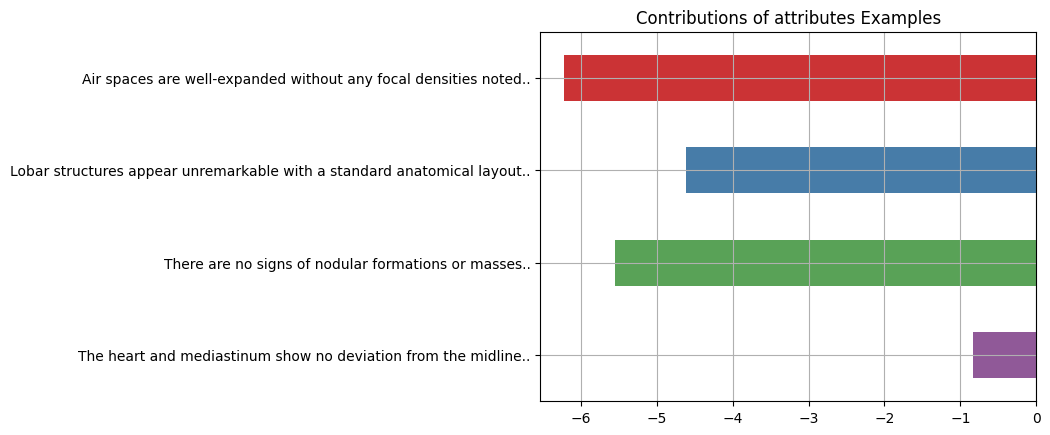

In [21]:
cmap = matplotlib.colormaps.get_cmap('jet')
cam_ids = list(range(8, 12))
example_weights_ = example_weights[cam_ids]
example_left_lung_descripts = [left_lung_descripts[idx] for idx in cam_ids]


sns.barplot(x=example_weights_, y=example_left_lung_descripts, width=0.5, palette='Set1')
plt.title("Contributions of attributes Examples")
plt.grid(True)

In [22]:
images = abatch['pixel_values'][0]
images.shape

torch.Size([3, 224, 224])

In [23]:
cams = abatch['inter_map'][0]
cams.shape


torch.Size([128, 7, 7])

In [24]:
cams = cams[cam_ids]
cams.shape

torch.Size([4, 7, 7])

In [25]:
def min_max_normalize(cams):
    
    mim_cams, _ = torch.min(cams.reshape(4, -1), dim=1, keepdims=True)
    max_cams, _ = torch.max(cams.reshape(4, -1), dim=1, keepdims=True)
    nonzero_max = (max_cams > 0).to(torch.float32)
    max_usdfs = torch.where(max_cams > 0, max_cams, 1e-6)

    return nonzero_max[..., None, None] * (cams - mim_cams[:, None, None]) / (max_cams[:, None, None] - mim_cams[:, None, None])

In [26]:
cams = cams * example_weights_[:, None, None]
cams = F.interpolate(cams[:, None, ...], size=(224, 224), mode='bilinear')
cams = min_max_normalize(cams)
heatmap = cmap(cams)[..., :3][:, 0]

In [27]:
heatmap.shape


(4, 224, 224, 3)

In [28]:

images = images.permute(1, 2, 0).unsqueeze(0)

images.shape

torch.Size([1, 224, 224, 3])

In [29]:
mixed = 0.6 * images + 0.4 * heatmap

In [30]:
mixed.shape

torch.Size([4, 224, 224, 3])

2025-02-21 04:07:42,525 - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
2025-02-21 04:07:42,526 - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
2025-02-21 04:07:42,527 - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
2025-02-21 04:07:42,527 - Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


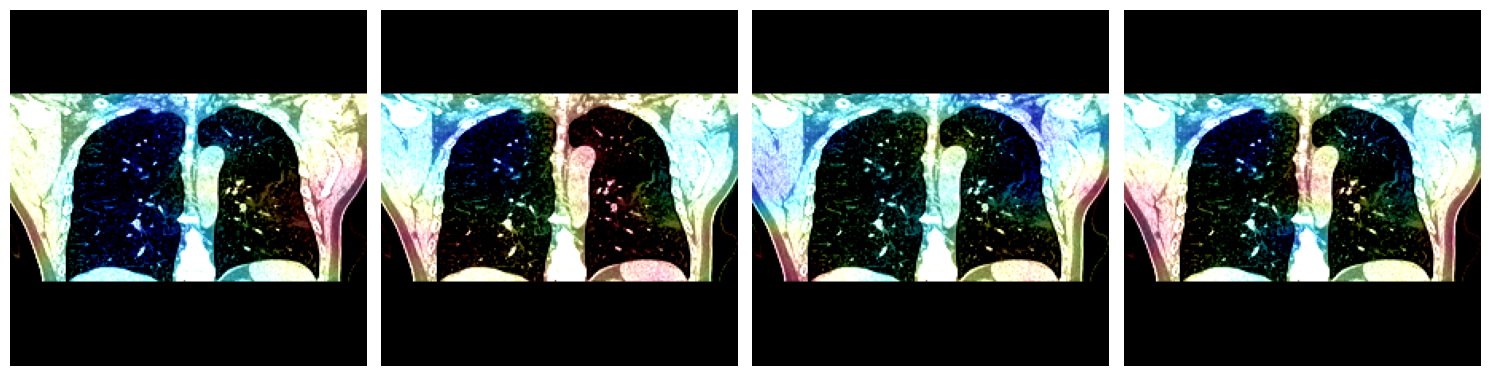

In [31]:
fig, axs = plt.subplots(1, 4, figsize=(15, 5))

for i in range(4):
    axs[i].imshow(mixed[i].cpu().numpy(), cmap='viridis')
    axs[i].axis('off') 

plt.tight_layout()

